## Investigating the Range as a Function of the Angle of Projection

## **Step 1: Establish the Theoretical Foundation**
# **Projectile Motion with Air Resistance**  

## **1. Equations of Motion**  
- The equations governing projectile motion with air resistance are derived from Newton’s second law. We consider a projectile of mass $m$ moving under the influence of gravity and an opposing air resistance force proportional to velocity.  

The equations of motion are given by:  

$$
m \cdot x'' = -b \cdot x'
$$

$$
m \cdot y'' = -mg - b \cdot y'
$$

### **Where:**
- $m$ = mass of the projectile (kg)  
- $g$ = gravitational acceleration (9.81 m/s²)  
- $b$ = air resistance coefficient (kg/s)  
- $x', y'$ = velocity components  

---

## **2. Initial Conditions**  
The initial conditions define the starting point and initial velocity components of the projectile.  

$$
x_0 = 0, \quad y_0 = 0
$$

(Starting position at the origin)  

$$
v_{x0} = 10, \quad v_{y0} = 10
$$

(Initial velocity components in m/s)  

---

## **3. Deriving the Equations of Motion**  

### **Step 1: Solve for Horizontal Motion**  
From the equation:

$$
m \cdot x'' = -b \cdot x'
$$

Rewriting:

$$
x'' + \frac{b}{m} x' = 0
$$

This is a first-order linear differential equation in $x'$. The general solution for velocity is:

$$
x'(t) = v_{x0} e^{-\frac{b}{m} t}
$$

To find the horizontal displacement, integrate:

$$
x(t) = \frac{m}{b} v_{x0} \left( 1 - e^{-\frac{b}{m} t} \right)
$$

---

### **Step 2: Solve for Vertical Motion**  
From the vertical motion equation:

$$
m \cdot y'' = -mg - b \cdot y'
$$

Rewriting:

$$
y'' + \frac{b}{m} y' + g = 0
$$

Solving for $y'$:

$$
y'(t) = \left( v_{y0} + \frac{mg}{b} \right) e^{-\frac{b}{m} t} - \frac{mg}{b}
$$

Integrating to get $y(t)$:

$$
y(t) = \frac{m}{b} \left( v_{y0} + \frac{mg}{b} \right) \left( 1 - e^{-\frac{b}{m} t} \right) - \frac{mg}{b} t
$$

For small air resistance ($b \approx 0$), this simplifies to:

$$
y(t) = v_0 \sin \theta \cdot t - \frac{1}{2} g t^2
$$

---

## **4. Calculate the Time of Flight**  
The projectile reaches the ground when $y = 0$. Using the simplified equation:

$$
y(t) = v_0 \sin \theta \cdot t - \frac{1}{2} g t^2
$$

Setting $y = 0$ and solving for $t$:

$$
t \left( v_0 \sin \theta - \frac{1}{2} g t \right) = 0
$$

This gives two solutions:

$$
t = 0 \quad \text{(initial time)}
$$

$$
t = \frac{2 v_0 \sin \theta}{g}
$$

Thus, the total time of flight is:

$$
T = \frac{2 v_0 \sin \theta}{g}
$$


#### **4. Derive the Range Equation**
- The range is the horizontal distance at $T$:

  $$ R = v_0 \cos\theta \cdot T$$

- Substituting $T$:

  $$
  R = v_0 \cos \theta \cdot \frac{2 v_0 \sin \theta}{g}
  $$

- Using the trigonometric identity $2 \sin \theta \cos \theta = \sin 2\theta$ , we obtain:

  $$
  R = \frac{v_0^2 \sin 2\theta}{g}
  $$

#### **5. Find the Optimal Angle for Maximum Range**
- The range depends on $\sin 2\theta$, which is maximized when $2\theta = 90^\circ$, or $\theta = 45^\circ$.
- Thus, the optimal angle for maximum range is $45^\circ$.

### **Step 3: Analyze How Range Changes with Angle**

#### **1. Varying the Angle from 0° to 90°**
- Compute $R$ for multiple angles and observe how it changes.

#### **2. Effects of Initial Velocity**
- Increase or decrease $v_0$ and check how it impacts $ R $.

#### **3. Effects of Gravity**
- Consider different values of $g$ (e.g., Earth vs. Moon) and see how the range varies.

#### **4. Find the Symmetry**
- The equation $R = \frac{v_0^2}{g} \sin 2\theta$ is **symmetric**, meaning:

  $\theta = 30^\circ$
   and 
  $\theta = 60^\circ$ give the same range.

  $\theta = 20^\circ$
   and 
  $\theta = 70^\circ$ also give the same range.

---

### **Step 4: Practical Applications**

#### **1. Sports Applications**
- Optimizing kick angles in soccer, golf, or basketball for maximum range.

#### **2. Ballistics & Military Applications**
- Determining the best firing angle for artillery.

#### **3. Rocket Science**
- Understanding launch angles for spacecraft trajectories.

---

### **Step 5: Implementation in Python**

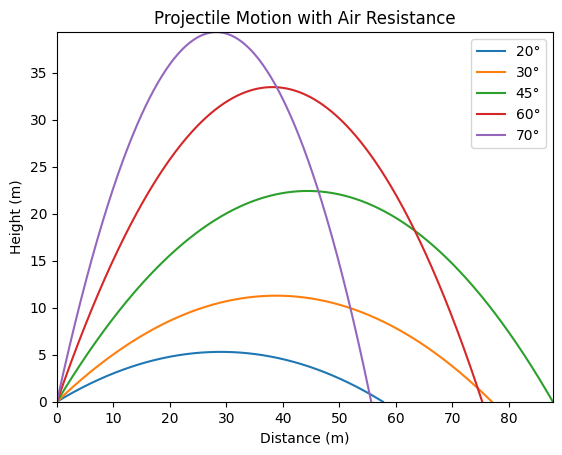

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Constants
g = 9.81  # Gravity (m/s^2)
rho = 1.225  # Air density (kg/m^3)
Cd = 0.47  # Drag coefficient (approx for a sphere)
r = 0.05  # Projectile radius (m)
m = 0.145  # Mass of projectile (kg)
A = np.pi * r**2  # Cross-sectional area (m^2)
c = 0.5 * Cd * rho * A  # Drag constant

def simulate_projectile(v0, angle, dt=0.001, max_time=10):
    """Simulates projectile motion with air resistance using smaller time steps for accuracy."""
    theta = np.radians(angle)
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    x, y = [0], [0]
    t = 0
    
    while y[-1] >= 0:
        v = np.sqrt(vx**2 + vy**2)
        drag_force = c * v  # Drag force magnitude
        ax = -drag_force/m * vx / v
        ay = -g - (drag_force/m * vy / v)
        
        vx += ax * dt
        vy += ay * dt
        
        x.append(x[-1] + vx * dt)
        y.append(y[-1] + vy * dt)
        t += dt
        
        if t >= max_time and y[-1] < 0:
            break
    
    return x, y

# Parameters
angles = [20, 30, 45, 60, 70]  # Different launch angles
v0 = 30  # Initial speed (m/s)

# Generate trajectories
trajectories = [simulate_projectile(v0, angle) for angle in angles]

# Create animation
fig, ax = plt.subplots()
ax.set_xlim(0, max(max(x) for x, _ in trajectories))
ax.set_ylim(0, max(max(y) for _, y in trajectories))
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Height (m)")
ax.set_title("Projectile Motion with Air Resistance")
lines = [ax.plot([], [], label=f"{angle}°")[0] for angle in angles]
ax.legend()

def update(frame):
    for i, line in enumerate(lines):
        x, y = trajectories[i]
        line.set_data(x[:frame * 20], y[:frame * 20])  # Speed up animation
    return lines

ani = animation.FuncAnimation(fig, update, frames=700, interval=10, blit=True)  # Faster animation
ani.save("projectile_motion.gif", writer="pillow")
plt.show()



---

### **Step 6: Discussion & Limitations**

#### **1. What does the graph show?**
- A clear peak at $ \theta = 45^\circ $.
- Symmetry in range for complementary angles.
- $\theta = 30^\circ$
   and 
  $\theta = 60^\circ$ give nearly the same range.

  $\theta = 20^\circ$
   and 
  $\theta = 70^\circ$ also give nearly the same range.

#### **2. Limitations of the Model**
- Assumes flat ground .

#### **3. How to Improve the Model?**
- Add drag force.
- Consider different launch heights.



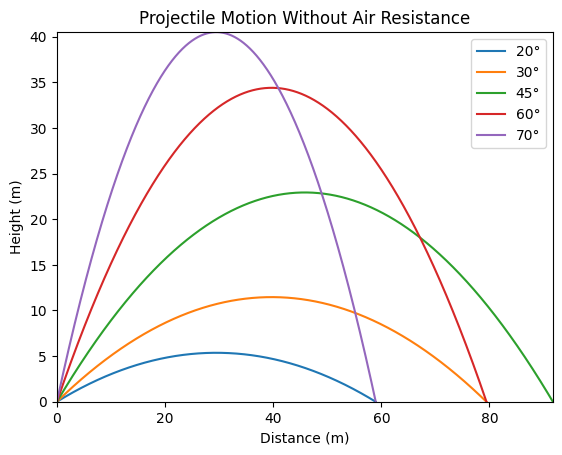

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Constants
g = 9.81  # Gravity (m/s^2)

def simulate_projectile(v0, angle, dt=0.001, max_time=10):
    """Simulates projectile motion without air resistance."""
    theta = np.radians(angle)
    vx, vy = v0 * np.cos(theta), v0 * np.sin(theta)
    x, y = [0], [0]
    t = 0
    
    while y[-1] >= 0:
        # Update velocities
        ax = 0  # No horizontal acceleration
        ay = -g  # Only gravity affects vertical acceleration
        
        vx += ax * dt
        vy += ay * dt
        
        # Update positions
        x.append(x[-1] + vx * dt)
        y.append(y[-1] + vy * dt)
        
        t += dt
        
        if t >= max_time and y[-1] < 0:
            break
    
    return x, y

# Parameters
angles = [20, 30, 45, 60, 70]  # Different launch angles
v0 = 30  # Initial speed (m/s)

# Generate trajectories
trajectories = [simulate_projectile(v0, angle) for angle in angles]

# Create animation
fig, ax = plt.subplots()
ax.set_xlim(0, max(max(x) for x, _ in trajectories))
ax.set_ylim(0, max(max(y) for _, y in trajectories))
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Height (m)")
ax.set_title("Projectile Motion Without Air Resistance")
lines = [ax.plot([], [], label=f"{angle}°")[0] for angle in angles]
ax.legend()

def update(frame):
    for i, line in enumerate(lines):
        x, y = trajectories[i]
        line.set_data(x[:frame * 20], y[:frame * 20])  # Speed up animation
    return lines

ani = animation.FuncAnimation(fig, update, frames=700, interval=10, blit=True)  # Faster animation
ani.save("projectile_motion_no_air_resistance.gif", writer="pillow")
plt.show()